In [1]:
import matplotlib.pyplot as plt
import numpy
import pandas
import functools 
import datetime
import scipy

import pmana.utils
import pmana.purity

#### Look at one single measurement

There were 4 used channels in this measurement.


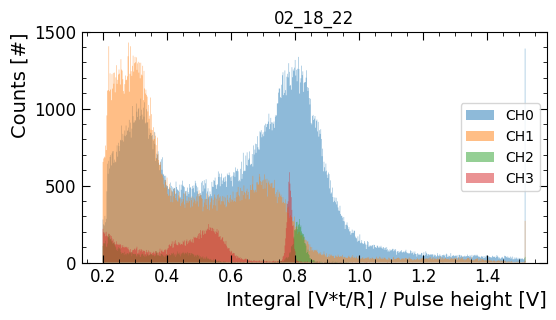

In [6]:
fig, ax = plt.subplots(figsize=(6,3))

YEAR = '2026'
MONTH = 'Mar'
MEASUREMENT = '02_18_22'

# extract a measurement 
Data = pmana.utils.io.ExtractSingleMeasurement(
    f"../../data/cern/{YEAR}_{MONTH}/Record_{YEAR}_{MONTH}_{MEASUREMENT}.csv",
    IS_CSV = True,
    COL_NAMES = ['binCenter', 'F1', 'F2', 'F3', 'F4'],
    DELIMITER = ","
)
print(f"There were {len(Data)} used channels in this measurement.")

CHs = [1, 2, 3, 4]
for ch in CHs:
    # plot channel data
    pmana.utils.plotting.PlotSingleChannel(
        Data[ch-1],
        ax,
        channel = ch-1,
        rebin = False,
        debug = False,
        DISPLAY_FIT = False
    )

ax = pmana.utils.plotting.UpdateMatplotlibStyle(
    ax,
    "Integral [V*t/R] / Pulse height [V]",
    "Counts [#]"
)

ax.legend()
ax.set_title(f"{MEASUREMENT}")
plt.show()

In [9]:
CalibrationFactors = {
  0: 1,
  1: 1,
  2: 0.8,
  3: 0.8
}

ANALYSIS_CONFIGURATION = {
    'InnerLongChannel'          : 0,
    'OuterLongChannel'          : 1,
    'InnerShortChannel'         : 3,
    'OuterShortChannel'         : 2,  
    'ShortGausFitLimits'        : (0.15, 0.15),
    'LongGausFitLimits'         : (0.15, 0.15),
    'ComptonSearchLimits'       : (0.4, 1),
    'MinComptonSearchLowLimit'  : 0.25,
    'ComptonMode'               : 'rising'
}

pmana.purity.ana.ExtractICPeak(
  Data,
  CalibrationFactors,
  PM_TAG = 'Short',
  ANALYSIS_CONFIGURATION = ANALYSIS_CONFIGURATION
)

103 0.407
59.52499999999999 60.025


(np.float64(0.8563467578260068),
 np.float64(0.0767316599493175),
 np.float64(0.991670137442732))